In [4]:
!conda install git -y

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/miniconda3

  added / updated specs:
    - git


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    git-2.51.0                 | pl5382hee26aef_1        10.4 MB
    perl-5.42.2                | 1_haa24f5a_perl5        11.7 MB
    ------------------------------------------------------------
                                           Total:        22.2 MB

The following NEW packages will be INSTALLED:

  git                pkgs/main/osx-arm64::git-2.51.0-pl5382hee26aef_1 
  perl               pkgs/main/osx-arm64::perl-5.42.2-1_haa24f5a_perl5 



perl-5.42.2          | 11.7 MB   |                                       |   0% 
perl-5.42.2          | 11.7 MB   |                                       

In [5]:
!git --version

git version 2.51.0


In [3]:
import numpy as np
import pandas as pd

np.random.seed(1)

state = 0
temperature = 0.9
discount = 0.9
learning_rate = 0.1
actions = ["left", "right"]
Q = np.zeros((5, 2)) 
history = []

In [4]:
def step(state, action):
    if action == "left":
        action = -1
    else:
        action = 1
        
    new_state = state + action
    
    if new_state < 0:
        new_state = max(0, new_state)
    elif new_state > 4:
        new_state = min(4, new_state)

    if new_state == 4:
        reward = 1
    else:
        reward = 0
    return new_state, reward

In [5]:
for trial in range (1,1001):
    exp_values = np.exp(Q[state] / temperature)
    probs = exp_values/ np.sum(exp_values)
    action = np.random.choice(["left","right"], p = probs)
    old_state = state
    new_state, reward = step(state,action)
    a_i = actions.index(action)
    target = reward + discount * np.max(Q[new_state])
    prediction_error = target - Q[state, a_i]
    Q[state, a_i] = Q[state, a_i] + learning_rate * prediction_error

    history.append ({
        "time": trial,
        "old_state": old_state,
        "action": action,
        "new_state": new_state,
        "reward": reward,
        "q_left": Q[old_state, 0],
        "q_right": Q[old_state, 1],
        "prediction_error": prediction_error
    })
    
    state = new_state
    if state == 4:
        state = 0
history

df_1 = pd.DataFrame(history)
df_1.iloc[300:401]

,time,old_state,action,new_state,reward,q_left,q_right,prediction_error
300,301,0,right,1,0,0.245659,0.384663,0.092876
301,302,1,right,2,0,0.175487,0.533122,0.128416
302,303,2,right,3,0,0.173224,0.732881,0.121077
303,304,3,right,4,1,0.243380,0.941850,0.064611
304,305,0,left,0,0,0.255713,0.384663,0.100538
...,...,...,...,...,...,...,...,...
396,397,2,left,1,0,0.465908,0.825364,0.175579
397,398,1,right,2,0,0.358358,0.698212,0.049573
398,399,2,right,3,0,0.465908,0.830046,0.046823
399,400,3,right,4,1,0.462645,0.972187,0.030903


In [43]:
!git add .
!git commit -m "saved work"

[master 5df1fdf] saved work
 Committer: Albert Roca Saura <roca@Alberts-MacBook-Air.local>
Your name and email address were configured automatically based
on your username and hostname. Please check that they are accurate.
You can suppress this message by setting them explicitly. Run the
following command and follow the instructions in your editor to edit
your configuration file:

    git config --global --edit

After doing this, you may fix the identity used for this commit with:

    git commit --amend --reset-author

 1 file changed, 83 insertions(+), 760 deletions(-)


In [44]:
!git status

On branch master
nothing to commit, working tree clean


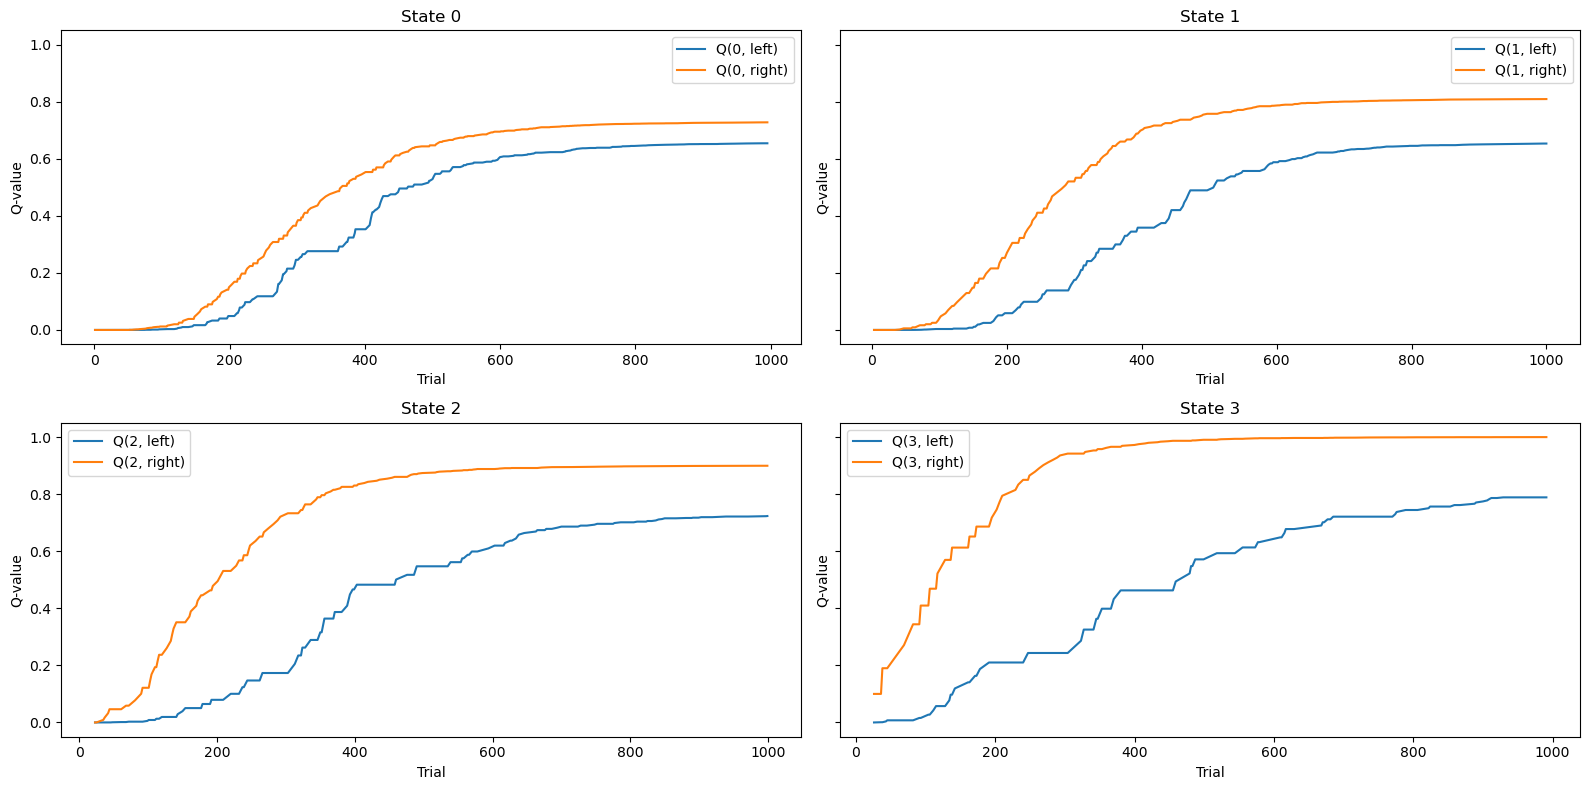

In [12]:
#Ploting Q-value evolution state 3
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharey=True)

df_1_s3 = df_1[df_1["old_state"] == 3]
axes[1,1].plot(df_1_s3["time"], df_1_s3["q_left"], label="Q(3, left)")
axes[1,1].plot(df_1_s3["time"], df_1_s3["q_right"], label="Q(3, right)")
axes[1,1].set_xlabel("Trial")
axes[1,1].set_ylabel("Q-value")
axes[1,1].set_title("State 3")
axes[1,1].legend()

df_1_s2 = df_1[df_1["old_state"] == 2]
axes[1,0].plot(df_1_s2["time"], df_1_s2["q_left"], label="Q(2, left)")
axes[1,0].plot(df_1_s2["time"], df_1_s2["q_right"], label="Q(2, right)")
axes[1,0].set_xlabel("Trial")
axes[1,0].set_ylabel("Q-value")
axes[1,0].set_title("State 2")
axes[1,0].legend()

df_1_s1 = df_1[df_1["old_state"] == 1]
axes[0,1].plot(df_1_s1["time"], df_1_s1["q_left"], label="Q(1, left)")
axes[0,1].plot(df_1_s1["time"], df_1_s1["q_right"], label="Q(1, right)")
axes[0,1].set_xlabel("Trial")
axes[0,1].set_ylabel("Q-value")
axes[0,1].set_title("State 1")
axes[0,1].legend()

df_1_s0 = df_1[df_1["old_state"] == 0]
axes[0,0].plot(df_1_s0["time"], df_1_s0["q_left"], label="Q(0, left)")
axes[0,0].plot(df_1_s0["time"], df_1_s0["q_right"], label="Q(0, right)")
axes[0,0].set_xlabel("Trial")
axes[0,0].set_ylabel("Q-value")
axes[0,0].set_title("State 0")
axes[0,0].legend()

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Prediction error')

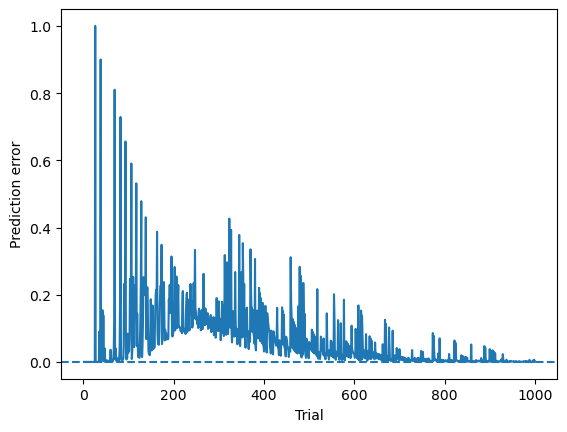

In [13]:
plt.plot(df_1["time"], df_1["prediction_error"])
plt.axhline(0, linestyle="--")
plt.xlabel("Trial")
plt.ylabel("Prediction error")

In [1]:
!git add .
!git commit -m "saved work"

[master 452315d] saved work
 Committer: Albert Roca Saura <roca@Alberts-MacBook-Air.local>
Your name and email address were configured automatically based
on your username and hostname. Please check that they are accurate.
You can suppress this message by setting them explicitly. Run the
following command and follow the instructions in your editor to edit
your configuration file:

    git config --global --edit

After doing this, you may fix the identity used for this commit with:

    git commit --amend --reset-author

 2 files changed, 391 insertions(+), 781 deletions(-)


In [ ]:
!git remote add origin https://github.com/AlviRK/RL_simulations_internship.git
!git branch -M main
!git push -u origin main

Username for 'https://github.com': 

In [ ]:
!pwd